# 08 — Integración RUP: indicadores financieros para NO-consorcios

**Objetivo**: Añadir al dataset depurado los indicadores financieros del RUP
(Registro Único de Proponentes) para los contratos cuyo proveedor adjudicado
**no** es un consorcio / unión temporal.

**Regla de negocio**:
- Si `es_grupo == 'No'` → cruzar con RUP por NIT y traer indicadores financieros.
- Si `es_grupo == 'Si'` → dejar los indicadores en `null` (se procesarán en un flujo separado específico para consorcios).

**Columnas a añadir** (5 indicadores financieros del RUP):
- `rup_idx_endeudamiento`
- `rup_idx_liquidez`
- `rup_ingresos`
- `rup_utilidad_neta`
- `rup_multas`

> Nota: `rup_idx_cobertura` se omite porque está 100% vacía en el dataset RUP.

**Pipeline de cruce**:
```
contratos_depurado_modelo (o contratos_adiciones_obra)
    │
    ▼ (si es_grupo == 'No' y tipodocproveedor == 'NIT')
    │   documento_proveedor → llave NIT
    ▼
proveedores_rup (por nit) → trae los 5 indicadores
```

---

## 1. Configuración y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATA_DIR = '../data/'
print('Configuración lista.')

Configuración lista.


In [2]:
# Dataset principal: tabla integrada completa (tiene es_grupo, tipodocproveedor, documento_proveedor)
df = pd.read_parquet(DATA_DIR + 'contratos_adiciones_obra.parquet')

# Dataset RUP
df_rup = pd.read_parquet(DATA_DIR + 'proveedores_rup.parquet')

print(f'Contratos: {df.shape}')
print(f'RUP: {df_rup.shape}')

print(f'\nDistribución es_grupo:')
print(df['es_grupo'].value_counts())

print(f'\nDistribución tipodocproveedor:')
print(df['tipodocproveedor'].value_counts())

Contratos: (48331, 114)
RUP: (28548, 22)

Distribución es_grupo:
es_grupo
No    37702
Si    10629
Name: count, dtype: int64

Distribución tipodocproveedor:
tipodocproveedor
NIT                                36965
Cédula de Ciudadanía                6802
No Definido                         3469
Otro                                1080
Cédula de Extranjería                 13
Tarjeta de Identidad                   1
Permiso especial de permanencia        1
Name: count, dtype: int64


## 2. Preparación del dataset RUP

El RUP tiene 22 columnas, pero solo necesitamos 5 indicadores financieros + la llave `nit`.

In [3]:
# Columnas RUP a incorporar
COLS_RUP = [
    'rup_idx_endeudamiento',
    'rup_idx_liquidez',
    'rup_ingresos',
    'rup_utilidad_neta',
    'rup_multas',
]

# Verificar disponibilidad de datos en RUP
print('=== Disponibilidad de indicadores RUP (todos los proveedores) ===')
for col in COLS_RUP:
    no_null = df_rup[col].notna().sum()
    pct = no_null / len(df_rup) * 100
    print(f'  {col:25s}: {no_null:>6,} / {len(df_rup):,} ({pct:.1f}%)')

# Deduplicar RUP por NIT (no debería haber duplicados, pero por seguridad)
print(f'\nRUP: {df_rup["nit"].duplicated().sum()} duplicados por NIT')
df_rup = df_rup.drop_duplicates(subset=['nit'], keep='first')

# Seleccionar solo las columnas necesarias
rup_slim = df_rup[['nit'] + COLS_RUP].copy()
print(f'\nRUP compacto: {rup_slim.shape}')

=== Disponibilidad de indicadores RUP (todos los proveedores) ===
  rup_idx_endeudamiento    : 10,407 / 28,548 (36.5%)
  rup_idx_liquidez         : 10,292 / 28,548 (36.1%)
  rup_ingresos             : 13,132 / 28,548 (46.0%)
  rup_utilidad_neta        : 13,166 / 28,548 (46.1%)
  rup_multas               : 13,530 / 28,548 (47.4%)

RUP: 0 duplicados por NIT

RUP compacto: (28548, 6)


## 3. Conversión de tipos: `rup_ingresos` y `rup_utilidad_neta` vienen como string

Para poder modelar con estos valores hay que pasarlos a numérico.

In [4]:
# Ver tipos originales
print('Dtypes originales:')
print(rup_slim.dtypes)

# Convertir a numérico (errores -> NaN)
for col in ['rup_ingresos', 'rup_utilidad_neta']:
    rup_slim[col] = pd.to_numeric(rup_slim[col], errors='coerce')

print('\nDtypes después de conversión:')
print(rup_slim.dtypes)

print('\n=== Estadísticas de indicadores RUP ===')
print(rup_slim[COLS_RUP].describe().round(2))

Dtypes originales:
nit                          str
rup_idx_endeudamiento    float64
rup_idx_liquidez         float64
rup_ingresos                 str
rup_utilidad_neta            str
rup_multas               float64
dtype: object

Dtypes después de conversión:
nit                          str
rup_idx_endeudamiento    float64
rup_idx_liquidez         float64
rup_ingresos             float64
rup_utilidad_neta        float64
rup_multas               float64
dtype: object

=== Estadísticas de indicadores RUP ===
       rup_idx_endeudamiento  rup_idx_liquidez  rup_ingresos  \
count               10407.00          10292.00  1.313200e+04   
mean                   26.07            136.44  9.542587e+09   
std                  2616.69           3540.92  1.827253e+11   
min                    -0.01           -162.73  0.000000e+00   
25%                     0.07              2.73  7.416625e+07   
50%                     0.22              7.14  6.599802e+08   
75%                     0.46         

## 4. Construcción de la llave de cruce en el dataset de contratos

**Regla**: solo intentamos cruzar con RUP los contratos que cumplen las 2 condiciones:
1. `es_grupo == 'No'` (no es consorcio/unión temporal)
2. `tipodocproveedor == 'NIT'` (el documento_proveedor es un NIT de empresa)

Los demás contratos (consorcios, personas naturales con cédula, "No Definido") se dejan con indicadores nulos.

In [5]:
# Flag: contrato elegible para cruce con RUP
df['_elegible_rup'] = (
    (df['es_grupo'] == 'No') &
    (df['tipodocproveedor'] == 'NIT')
)

# Construir la llave NIT solo para elegibles
df['_nit_para_rup'] = df['documento_proveedor'].where(df['_elegible_rup'])

n_elegibles = df['_elegible_rup'].sum()
n_consorcios = (df['es_grupo'] == 'Si').sum()
n_no_elegibles = len(df) - n_elegibles - n_consorcios

print(f'=== Clasificación de contratos ===')
print(f'Total contratos:              {len(df):>7,}')
print(f'  Elegibles para RUP          {n_elegibles:>7,} ({n_elegibles/len(df)*100:.1f}%)  — es_grupo=No + NIT')
print(f'  Consorcios (se procesan ap.) {n_consorcios:>7,} ({n_consorcios/len(df)*100:.1f}%)  — es_grupo=Si')
print(f'  No elegibles (sin NIT)       {n_no_elegibles:>7,} ({n_no_elegibles/len(df)*100:.1f}%)  — cédula / otro / No definido')

=== Clasificación de contratos ===
Total contratos:               48,331
  Elegibles para RUP           30,197 (62.5%)  — es_grupo=No + NIT
  Consorcios (se procesan ap.)  10,629 (22.0%)  — es_grupo=Si
  No elegibles (sin NIT)         7,505 (15.5%)  — cédula / otro / No definido


## 5. Cruce con RUP (LEFT JOIN)

In [6]:
# LEFT JOIN: traer indicadores RUP solo para contratos elegibles
df_con_rup = df.merge(
    rup_slim,
    left_on='_nit_para_rup', right_on='nit',
    how='left'
)

# Verificar que no hubo multiplicación de filas
print(f'Filas antes del merge: {len(df):,}')
print(f'Filas después del merge: {len(df_con_rup):,}')
assert len(df_con_rup) == len(df), 'Error: el merge multiplicó filas'
print('✓ Sin multiplicación de filas')

# Eliminar la columna auxiliar nit (redundante con _nit_para_rup)
df_con_rup.drop(columns=['nit'], inplace=True)

Filas antes del merge: 48,331
Filas después del merge: 48,331
✓ Sin multiplicación de filas


In [7]:
# ============================================================
# Medir cobertura del cruce
# ============================================================
elegibles = df_con_rup[df_con_rup['_elegible_rup']]

# Usamos rup_multas como proxy (es el indicador con mayor cobertura)
con_rup = elegibles['rup_multas'].notna().sum()
sin_rup = len(elegibles) - con_rup

print(f'=== Cobertura del cruce contratos elegibles → RUP ===')
print(f'Contratos elegibles:               {len(elegibles):>7,}')
print(f'  Con al menos un indicador RUP:   {con_rup:>7,} ({con_rup/len(elegibles)*100:.1f}%)')
print(f'  Sin match en RUP (proveedor no registrado): {sin_rup:>7,} ({sin_rup/len(elegibles)*100:.1f}%)')

# Cobertura detallada por indicador
print(f'\n=== Disponibilidad por indicador (sobre elegibles = {len(elegibles):,}) ===')
for col in COLS_RUP:
    n = elegibles[col].notna().sum()
    print(f'  {col:25s}: {n:>7,} ({n/len(elegibles)*100:.1f}%)')

# Cobertura sobre el dataset total
print(f'\n=== Disponibilidad por indicador (sobre total = {len(df):,}) ===')
for col in COLS_RUP:
    n = df_con_rup[col].notna().sum()
    print(f'  {col:25s}: {n:>7,} ({n/len(df)*100:.1f}%)')

=== Cobertura del cruce contratos elegibles → RUP ===
Contratos elegibles:                30,197
  Con al menos un indicador RUP:    19,464 (64.5%)
  Sin match en RUP (proveedor no registrado):  10,733 (35.5%)

=== Disponibilidad por indicador (sobre elegibles = 30,197) ===
  rup_idx_endeudamiento    :  17,621 (58.4%)
  rup_idx_liquidez         :  17,448 (57.8%)
  rup_ingresos             :  19,303 (63.9%)
  rup_utilidad_neta        :  19,309 (63.9%)
  rup_multas               :  19,464 (64.5%)

=== Disponibilidad por indicador (sobre total = 48,331) ===
  rup_idx_endeudamiento    :  17,621 (36.5%)
  rup_idx_liquidez         :  17,448 (36.1%)
  rup_ingresos             :  19,303 (39.9%)
  rup_utilidad_neta        :  19,309 (40.0%)
  rup_multas               :  19,464 (40.3%)


## 6. Distribución de los indicadores

Visualizar los indicadores para detectar outliers y anomalías antes de modelar.

In [8]:
# Estadísticas descriptivas
print('=== Estadísticas de indicadores RUP (solo valores no nulos) ===')
desc = df_con_rup[COLS_RUP].describe().round(2)
print(desc)

=== Estadísticas de indicadores RUP (solo valores no nulos) ===
       rup_idx_endeudamiento  rup_idx_liquidez  rup_ingresos  \
count               17621.00          17448.00  1.930300e+04   
mean                    0.40            161.27  2.080704e+10   
std                     7.26           4245.05  2.688016e+11   
min                    -0.01            -90.44  0.000000e+00   
25%                     0.06              3.72  4.775000e+08   
50%                     0.20             10.18  1.602018e+09   
75%                     0.42             31.59  4.996314e+09   
max                   475.07         316426.67  1.546594e+13   

       rup_utilidad_neta  rup_multas  
count       1.930900e+04    19464.00  
mean       -1.371512e+09        0.02  
std         5.680392e+10        0.15  
min        -1.433180e+12        0.00  
25%         1.784219e+07        0.00  
50%         1.097036e+08        0.00  
75%         3.635469e+08        0.00  
max         2.251936e+12        3.00  


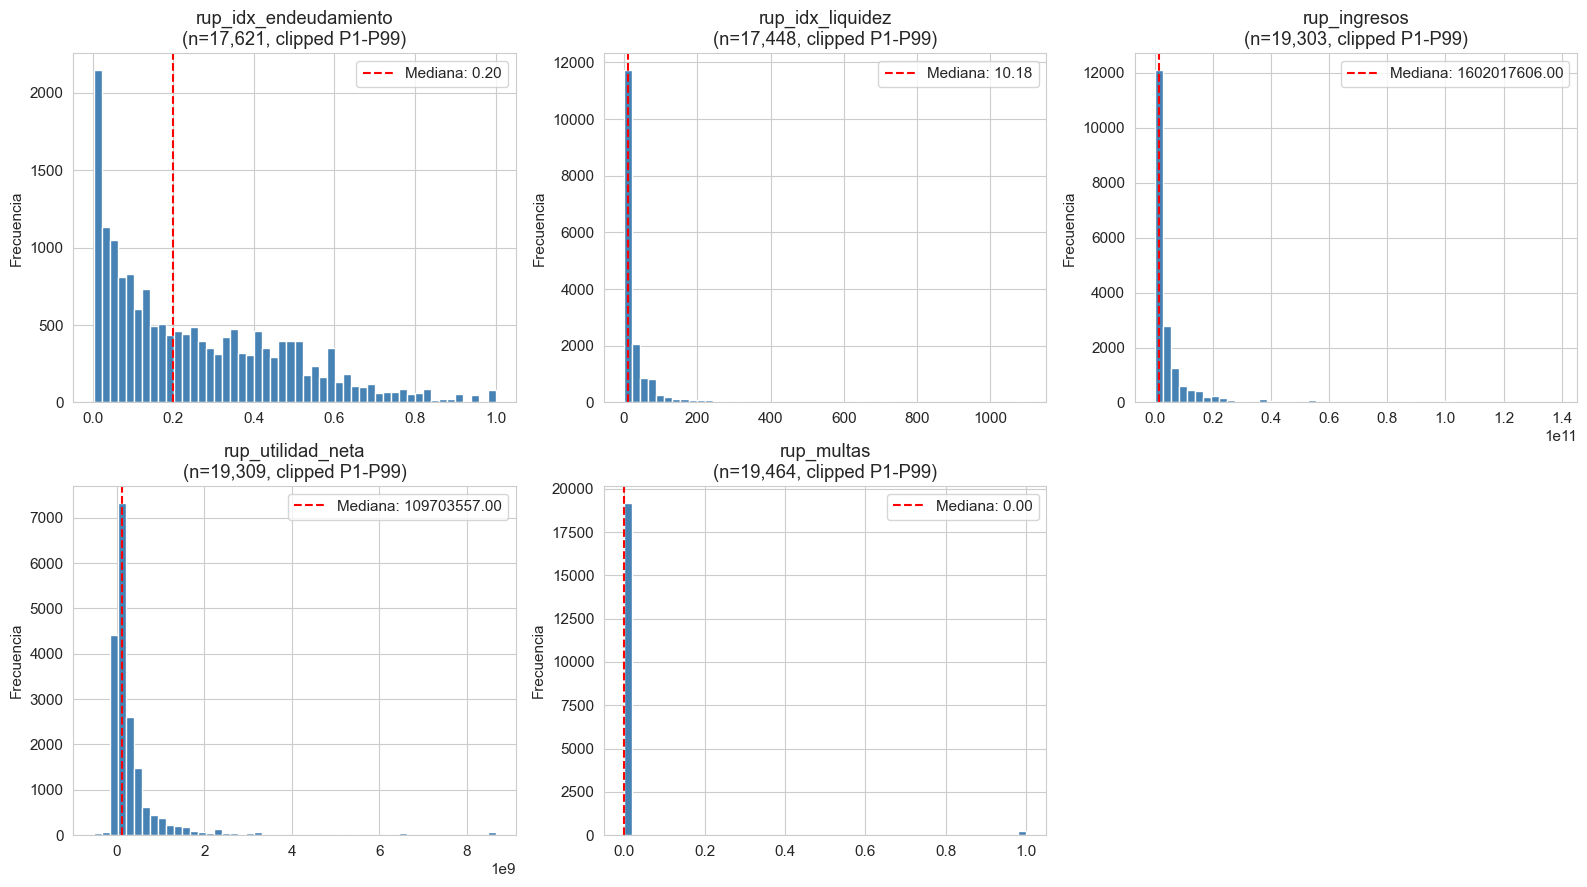

In [9]:
# Histogramas
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(COLS_RUP):
    data = df_con_rup[col].dropna()
    if len(data) == 0:
        axes[i].text(0.5, 0.5, f'{col}\n(sin datos)', ha='center', va='center')
        continue
    # Clip al P99 para visualizar
    p99 = data.quantile(0.99)
    p01 = data.quantile(0.01)
    data_clip = data[(data >= p01) & (data <= p99)]
    axes[i].hist(data_clip, bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}\n(n={len(data):,}, clipped P1-P99)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(data.median(), color='red', linestyle='--', label=f'Mediana: {data.median():.2f}')
    axes[i].legend()

# Ocultar el último subplot si sobra
for j in range(len(COLS_RUP), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 7. Validación: ¿los indicadores tienen relación con las variables objetivo?

Test rápido para verificar que los indicadores RUP aportan señal predictiva
(comparamos medianas por grupo target).

In [10]:
# Solo contratos con al menos un indicador RUP
tiene_rup = df_con_rup[df_con_rup['rup_multas'].notna()]

for target in ['alcance', 'presupuesto', 'tiempo']:
    print(f'\n=== {target.upper()} ===')
    stats = tiene_rup.groupby(target)[COLS_RUP].median().round(2).T
    stats.columns = [f'{target}=0 (con modif.)', f'{target}=1 (sin modif.)']
    stats['diferencia'] = (stats.iloc[:,0] - stats.iloc[:,1]).round(2)
    print(stats)


=== ALCANCE ===
                       alcance=0 (con modif.)  alcance=1 (sin modif.)  \
rup_idx_endeudamiento            2.500000e-01            2.000000e-01   
rup_idx_liquidez                 9.990000e+00            1.019000e+01   
rup_ingresos                     2.973591e+09            1.577180e+09   
rup_utilidad_neta                2.052427e+08            1.077858e+08   
rup_multas                       0.000000e+00            0.000000e+00   

                         diferencia  
rup_idx_endeudamiento  5.000000e-02  
rup_idx_liquidez      -2.000000e-01  
rup_ingresos           1.396411e+09  
rup_utilidad_neta      9.745690e+07  
rup_multas             0.000000e+00  

=== PRESUPUESTO ===
                       presupuesto=0 (con modif.)  presupuesto=1 (sin modif.)  \
rup_idx_endeudamiento                2.000000e-01                2.000000e-01   
rup_idx_liquidez                     1.071000e+01                1.002000e+01   
rup_ingresos                         1.767479e+09   

## 8. Limpieza y guardado

In [11]:
# Eliminar columnas auxiliares
df_con_rup.drop(columns=['_elegible_rup', '_nit_para_rup'], inplace=True)

print(f'Dataset final: {df_con_rup.shape}')
print(f'\nColumnas RUP añadidas:')
for c in COLS_RUP:
    print(f'  - {c}')

# Guardar versión completa actualizada
output_full = DATA_DIR + 'contratos_adiciones_obra.parquet'
df_con_rup.to_parquet(output_full, index=False)

import os
size_mb = os.path.getsize(output_full) / (1024 * 1024)
print(f'\n✓ Guardado (completo): {output_full}')
print(f'  {len(df_con_rup):,} filas × {df_con_rup.shape[1]} columnas  ({size_mb:.1f} MB)')

Dataset final: (48331, 119)

Columnas RUP añadidas:
  - rup_idx_endeudamiento
  - rup_idx_liquidez
  - rup_ingresos
  - rup_utilidad_neta
  - rup_multas



✓ Guardado (completo): ../data/contratos_adiciones_obra.parquet
  48,331 filas × 119 columnas  (16.4 MB)


In [12]:
# ============================================================
# Actualizar también el dataset depurado para modelado
# ============================================================
df_dep = pd.read_parquet(DATA_DIR + 'contratos_depurado_modelo.parquet')

# Hacer merge usando id_contrato (que existe en df_con_rup pero fue eliminado del depurado)
# Usamos el índice posicional: ambos datasets tienen las mismas 48,331 filas en el mismo orden
# pero para ser seguros, reconstruimos la llave desde df_con_rup

# Traer id_contrato al depurado temporalmente para hacer el join
# Como el depurado se generó desde el mismo df en el mismo orden, podemos hacer asignación directa
assert len(df_dep) == len(df_con_rup), 'Los datasets no tienen el mismo número de filas'

for col in COLS_RUP:
    df_dep[col] = df_con_rup[col].values

# Guardar depurado actualizado
output_dep = DATA_DIR + 'contratos_depurado_modelo.parquet'
df_dep.to_parquet(output_dep, index=False)
size_mb_dep = os.path.getsize(output_dep) / (1024 * 1024)
print(f'✓ Guardado (depurado): {output_dep}')
print(f'  {len(df_dep):,} filas × {df_dep.shape[1]} columnas  ({size_mb_dep:.1f} MB)')

# Resumen final
print(f'\n=== RESUMEN FINAL ===')
print(f'Columnas en dataset depurado: {df_dep.shape[1]}')
print(f'Indicadores RUP añadidos (para no-consorcios):')
for col in COLS_RUP:
    n_no_null = df_dep[col].notna().sum()
    print(f'  {col:25s}: {n_no_null:>6,} contratos con valor ({n_no_null/len(df_dep)*100:.1f}%)')

✓ Guardado (depurado): ../data/contratos_depurado_modelo.parquet
  48,331 filas × 47 columnas  (1.8 MB)

=== RESUMEN FINAL ===
Columnas en dataset depurado: 47
Indicadores RUP añadidos (para no-consorcios):
  rup_idx_endeudamiento    : 17,621 contratos con valor (36.5%)
  rup_idx_liquidez         : 17,448 contratos con valor (36.1%)
  rup_ingresos             : 19,303 contratos con valor (39.9%)
  rup_utilidad_neta        : 19,309 contratos con valor (40.0%)
  rup_multas               : 19,464 contratos con valor (40.3%)


## 9. Próximos pasos pendientes

1. **Consorcios** (10,629 / 11,078 contratos con `es_grupo='Si'`): necesitan un flujo
   separado que:
   - Identifique los NITs de los miembros del consorcio (requiere fuente adicional o parsing del nombre).
   - Consulte RUP por cada miembro.
   - Agregue los indicadores financieros (ej: suma de ingresos, promedio de índices).
   - Además, añadir **indicadores organizacionales** (empleados, tamaño, municipio).

2. **Contratos no elegibles** (personas naturales, tipo "No definido"): permanecerán
   con nulos en los indicadores RUP. Para el modelo, considerar:
   - Indicador binario `tiene_datos_rup` (0/1).
   - Imputación por mediana dentro de subgrupos relevantes (ej: modalidad).

3. **`rup_idx_cobertura`**: omitida por estar 100% vacía. Si en futuras extracciones
   del RUP se recupera, se podría integrar.